### Calcolo multivariato


# Introduzione al calcolo multivariato

In molti problemi dell'informatica e dell'analisi dei dati una quantità dipende da più variabili contemporaneamente. Per esempio:

- il tempo di esecuzione di un algoritmo può dipendere dalla dimensione dell'input e dal numero di processori disponibili;
- la probabilità di classificare correttamente un dato può dipendere da diversi parametri del modello;
- il valore di una funzione di costo dipende generalmente da tutti i pesi di una rete neurale;
- l'intensità di un'immagine digitale dipende dalle coordinate spaziali del pixel.

Per descrivere matematicamente queste situazioni è necessario estendere il concetto di funzione reale di una variabile alle **funzioni di più variabili**.

Analogamente, i concetti di derivata prima e seconda vengono generalizzati mediante:

- le derivate parziali;
- il gradiente;
- la matrice hessiana;
- la matrice jacobiana.



## Funzioni di più variabili

Una funzione reale di due variabili associa a ogni coppia $(x,y)$ appartenente a un insieme $D\subseteq\mathbb{R}^2$ un numero reale:

$$
f:D\subseteq\mathbb{R}^2\longrightarrow\mathbb{R}.
$$

Scriveremo

$$
z=f(x,y).
$$

Le variabili $x$ e $y$ sono dette **variabili indipendenti**, mentre $z$ è la **variabile dipendente**.

Più in generale, una funzione reale di $n$ variabili è una funzione

$$
f:D\subseteq\mathbb{R}^n\longrightarrow\mathbb{R},
$$

che associa al vettore

$$
\mathbf{x}=(x_1,x_2,\ldots,x_n)^T
$$

il numero reale

$$
f(\mathbf{x})=f(x_1,x_2,\ldots,x_n).
$$

### Esempio 1

Consideriamo la funzione

$$
f(x,y)=x^2+y^2.
$$

Il dominio è tutto $\mathbb{R}^2$. Alcuni valori della funzione sono

$$
f(0,0)=0,\qquad f(1,2)=5,\qquad f(-1,3)=10.
$$

Il grafico di $f$ è la superficie

$$
z=x^2+y^2,
$$

che ha la forma di un paraboloide.

-

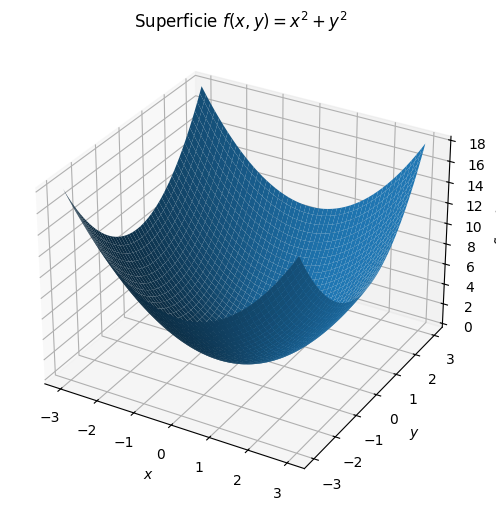

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Costruzione della griglia
x = np.linspace(-3, 3, 200)
y = np.linspace(-3, 3, 200)
X, Y = np.meshgrid(x, y)

# Valutazione della funzione
Z = X**2 + Y**2

# Grafico della superficie
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")

ax.plot_surface(X, Y, Z)

ax.set_xlabel("$x$")
ax.set_ylabel("$y$")
ax.set_zlabel("$f(x,y)$")
ax.set_title(r"Superficie $f(x,y)=x^2+y^2$")

plt.show()

### Esempio 2

La funzione

$$
f(x,y)=\sqrt{1-x^2-y^2}
$$

è definita soltanto quando

$$
1-x^2-y^2\geq 0.
$$

Il suo dominio è quindi il disco chiuso

$$
D=\left\{(x,y)\in\mathbb{R}^2:x^2+y^2\leq 1\right\}.
$$

Il grafico rappresenta la semisfera superiore di raggio $1$.

<p align="center">
  <img src="immagini_sorgente\fig2m.png"  width="400">
</p>

### Esempio 3

La funzione

$$
f(x,y)=\frac{1}{x-y}
$$

è definita per tutti i punti del piano tranne quelli appartenenti alla retta $x=y$.

Il dominio è

$$
D=\left\{(x,y)\in\mathbb{R}^2:x\neq y\right\}.
$$

### Una funzione di tre variabili

Una funzione di tre variabili ha la forma

$$
f:\mathbb{R}^3\longrightarrow\mathbb{R}.
$$

Per esempio,

$$
f(x,y,z)=x^2+y^2+z^2
$$

associa a ogni punto dello spazio il quadrato della sua distanza dall'origine.

In questo caso non è possibile rappresentare il grafico della funzione nello spazio tridimensionale, perché il grafico sarebbe un sottoinsieme di $\mathbb{R}^4$.

È però possibile studiare le **superfici di livello**.

--

## Curve e superfici di livello

Data una funzione

$$
f:\mathbb{R}^2\longrightarrow\mathbb{R},
$$

una curva di livello corrispondente al valore $c\in\mathbb{R}$ è l'insieme dei punti che soddisfano

$$
f(x,y)=c.
$$

Le curve di livello permettono di rappresentare una funzione di due variabili nel piano.

### Esempio

Per la funzione

$$
f(x,y)=x^2+y^2,
$$

le curve di livello sono descritte dall'equazione

$$
x^2+y^2=c.
$$

Se $c>0$, si ottengono circonferenze centrate nell'origine e di raggio $\sqrt{c}$.

Per $c=0$ si ottiene soltanto il punto $(0,0)$.




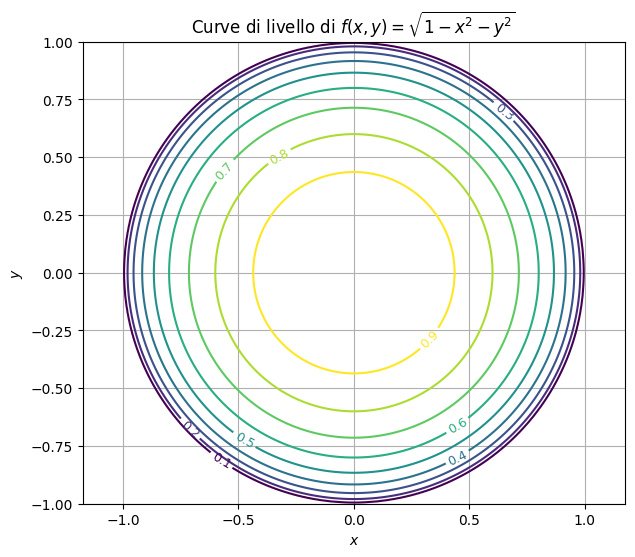

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Griglia sul dominio [-1,1] x [-1,1]
x = np.linspace(-1, 1, 400)
y = np.linspace(-1, 1, 400)
X, Y = np.meshgrid(x, y)

# La funzione è definita soltanto nel disco unitario
R2 = X**2 + Y**2
Z = np.full_like(X, np.nan)

mask = R2 <= 1
Z[mask] = np.sqrt(1 - R2[mask])

# Valori della funzione corrispondenti alle curve di livello
livelli = np.linspace(0.1, 0.9, 9)

plt.figure(figsize=(7, 6))

curve = plt.contour(X, Y, Z, levels=livelli)
plt.clabel(curve, inline=True, fontsize=9)

plt.xlabel("$x$")
plt.ylabel("$y$")
plt.title(
    r"Curve di livello di "
    r"$f(x,y)=\sqrt{1-x^2-y^2}$"
)

plt.axis("equal")
plt.grid()
plt.show()


Le curve di livello sono utilizzate, per esempio, nelle mappe geografiche: le curve che uniscono punti aventi la stessa altitudine sono dette **isoipse**.

Per una funzione di tre variabili

$$
f:\mathbb{R}^3\longrightarrow\mathbb{R},
$$

l'equazione

$$
f(x,y,z)=c
$$

descrive generalmente una superficie di livello.

Per esempio, per

$$
f(x,y,z)=x^2+y^2+z^2,
$$

le superfici di livello sono le sfere

$$
x^2+y^2+z^2=c,
$$

di centro l'origine e raggio $\sqrt{c}$.

---


## Derivate parziali

Per una funzione di una variabile, la derivata misura la variazione della funzione quando varia la sua unica variabile indipendente.

Per una funzione di più variabili possiamo invece studiare la variazione rispetto a una variabile alla volta, mantenendo fisse tutte le altre.

Sia

$$
f:\mathbb{R}^2\longrightarrow\mathbb{R}.
$$

La derivata parziale di $f$ rispetto a $x$ nel punto $(x,y)$ è definita da

$$
\frac{\partial f}{\partial x}(x,y)
=
\lim_{h\to 0}
\frac{f(x+h,y)-f(x,y)}{h},
$$

quando tale limite esiste.

Analogamente, la derivata parziale rispetto a $y$ è

$$
\frac{\partial f}{\partial y}(x,y)
=
\lim_{h\to 0}
\frac{f(x,y+h)-f(x,y)}{h}.
$$

Si utilizzano frequentemente anche le notazioni

$$
f_x(x,y)=\frac{\partial f}{\partial x}(x,y),
\qquad
f_y(x,y)=\frac{\partial f}{\partial y}(x,y).
$$

Nel calcolo di $f_x$, la variabile $y$ viene considerata costante.

Nel calcolo di $f_y$, la variabile $x$ viene considerata costante.

### Esempio 1

Consideriamo

$$
f(x,y)=x^2y+3xy^2.
$$

La derivata parziale rispetto a $x$ è

$$
f_x(x,y)
=
\frac{\partial}{\partial x}\left(x^2y+3xy^2\right)
=
2xy+3y^2.
$$

La derivata parziale rispetto a $y$ è

$$
f_y(x,y)
=
\frac{\partial}{\partial y}\left(x^2y+3xy^2\right)
=
x^2+6xy.
$$

Nel punto $(1,2)$ si ha

$$
f_x(1,2)=2\cdot 1\cdot 2+3\cdot 2^2=16,
$$

e

$$
f_y(1,2)=1^2+6\cdot 1\cdot 2=13.
$$

### Esempio 2

Sia

$$
f(x,y)=e^{xy}.
$$

Applicando la regola della derivata di una funzione composta, otteniamo

$$
f_x(x,y)=y e^{xy},
\qquad
f_y(x,y)=x e^{xy}.
$$

### Esempio 3

Consideriamo la funzione di tre variabili

$$
f(x,y,z)=x^2y+yz^3.
$$

Le tre derivate parziali sono

$$
f_x(x,y,z)=2xy,
$$

$$
f_y(x,y,z)=x^2+z^3,
$$

$$
f_z(x,y,z)=3yz^2.
$$

### Interpretazione geometrica

Per una funzione $z=f(x,y)$, la derivata parziale $f_x(x_0,y_0)$ rappresenta la pendenza della superficie nella direzione dell'asse $x$, mantenendo $y=y_0$ costante.

Analogamente, $f_y(x_0,y_0)$ rappresenta la pendenza nella direzione dell'asse $y$, mantenendo $x=x_0$ costante.

Le derivate parziali descrivono quindi come cambia la funzione muovendosi lungo le direzioni degli assi coordinati.

---


## Il gradiente

Le derivate parziali prime di una funzione scalare possono essere raccolte in un unico vettore, detto **gradiente**.

Per una funzione

$$
f:\mathbb{R}^n\longrightarrow\mathbb{R},
$$

il gradiente è definito come

$$
\nabla f(\mathbf{x})
=
\begin{pmatrix}
\displaystyle\frac{\partial f}{\partial x_1}(\mathbf{x})\\[2mm]
\displaystyle\frac{\partial f}{\partial x_2}(\mathbf{x})\\
\vdots\\
\displaystyle\frac{\partial f}{\partial x_n}(\mathbf{x})
\end{pmatrix}.
$$

Nel caso di una funzione di due variabili,

$$
\nabla f(x,y)
=
\begin{pmatrix}
f_x(x,y)\\
f_y(x,y)
\end{pmatrix}.
$$

Nel caso di tre variabili,

$$
\nabla f(x,y,z)
=
\begin{pmatrix}
f_x(x,y,z)\\
f_y(x,y,z)\\
f_z(x,y,z)
\end{pmatrix}.
$$

### Esempio

Consideriamo

$$
f(x,y)=x^2+2xy+3y^2.
$$

Le derivate parziali sono

$$
f_x(x,y)=2x+2y,
\qquad
f_y(x,y)=2x+6y.
$$

Pertanto,

$$
\nabla f(x,y)
=
\begin{pmatrix}
2x+2y\\
2x+6y
\end{pmatrix}.
$$

Nel punto $(1,-1)$ si ottiene

$$
\nabla f(1,-1)
=
\begin{pmatrix}
0\\
-4
\end{pmatrix}.
$$

### Interpretazione del gradiente

Il gradiente ha due importanti proprietà geometriche:

1. il vettore $\nabla f(x,y)$ indica la direzione di massima crescita locale della funzione;
2. il gradiente è perpendicolare alla curva di livello che passa per il punto considerato.

La direzione opposta,

$$
-\nabla f(x,y),
$$

è la direzione di massima diminuzione locale della funzione.

Questa osservazione è alla base del metodo del **gradiente discendente**, utilizzato in molti algoritmi di ottimizzazione e di apprendimento automatico.

### Esempio

Sia

$$
f(x,y)=x^2+y^2.
$$

Il gradiente è

$$
\nabla f(x,y)
=
\begin{pmatrix}
2x\\
2y
\end{pmatrix}.
$$

Nel punto $(1,2)$ si ha

$$
\nabla f(1,2)
=
\begin{pmatrix}
2\\
4
\end{pmatrix}.
$$

La funzione aumenta più rapidamente nella direzione del vettore $(2,4)^T$.

La direzione di massima diminuzione è invece $(-2,-4)^T$, che punta verso l'origine, cioè verso il punto di minimo della funzione.

---
</p>
  <img src="immagini_sorgente\fig3m.png"  width="400">
</p>


## Derivate parziali seconde

Le derivate parziali possono essere ulteriormente derivate.

Per una funzione di due variabili si definiscono le derivate parziali seconde

$$
f_{xx}
=
\frac{\partial^2 f}{\partial x^2},
\qquad
f_{yy}
=
\frac{\partial^2 f}{\partial y^2},
$$

e le derivate parziali miste

$$
f_{xy}
=
\frac{\partial^2 f}{\partial y\,\partial x},
\qquad
f_{yx}
=
\frac{\partial^2 f}{\partial x\,\partial y}.
$$

Per esempio,

$$
f_{xy}
=
\frac{\partial}{\partial y}
\left(
\frac{\partial f}{\partial x}
\right).
$$

Se le derivate parziali miste sono continue in un intorno del punto considerato, allora vale il teorema di Schwarz:

$$
f_{xy}=f_{yx}.
$$

### Esempio

Sia

$$
f(x,y)=x^3y^2+2xy.
$$

Le derivate prime sono

$$
f_x(x,y)=3x^2y^2+2y,
$$

$$
f_y(x,y)=2x^3y+2x.
$$

Le derivate seconde sono

$$
f_{xx}(x,y)=6xy^2,
$$

$$
f_{yy}(x,y)=2x^3,
$$

$$
f_{xy}(x,y)=6x^2y+2,
$$

$$
f_{yx}(x,y)=6x^2y+2.
$$

In questo caso si ha

$$
f_{xy}=f_{yx}.
$$

---

## La matrice hessiana

Le derivate parziali seconde di una funzione scalare vengono raccolte nella **matrice hessiana**.

Per una funzione

$$
f:\mathbb{R}^n\longrightarrow\mathbb{R},
$$

la matrice hessiana è

$$
\nabla^2 f(\mathbf{x})
=
\begin{pmatrix}
\displaystyle\frac{\partial^2 f}{\partial x_1^2}
&
\displaystyle\frac{\partial^2 f}{\partial x_1\partial x_2}
&
\cdots
&
\displaystyle\frac{\partial^2 f}{\partial x_1\partial x_n}
\\[2mm]
\displaystyle\frac{\partial^2 f}{\partial x_2\partial x_1}
&
\displaystyle\frac{\partial^2 f}{\partial x_2^2}
&
\cdots
&
\displaystyle\frac{\partial^2 f}{\partial x_2\partial x_n}
\\
\vdots & \vdots & \ddots & \vdots\\
\displaystyle\frac{\partial^2 f}{\partial x_n\partial x_1}
&
\displaystyle\frac{\partial^2 f}{\partial x_n\partial x_2}
&
\cdots
&
\displaystyle\frac{\partial^2 f}{\partial x_n^2}
\end{pmatrix}.
$$

Nel caso di una funzione di due variabili,

$$
\nabla^2 f(x,y)
=
\begin{pmatrix}
f_{xx}(x,y) & f_{xy}(x,y)\\
f_{yx}(x,y) & f_{yy}(x,y)
\end{pmatrix}.
$$

Se le derivate miste sono continue, la matrice hessiana è simmetrica:

$$
f_{xy}=f_{yx}.
$$

### Esempio 1

Consideriamo

$$
f(x,y)=x^2+2xy+3y^2.
$$

Il gradiente è

$$
\nabla f(x,y)
=
\begin{pmatrix}
2x+2y\\
2x+6y
\end{pmatrix}.
$$

Le derivate seconde sono

$$
f_{xx}=2,
\qquad
f_{xy}=2,
\qquad
f_{yx}=2,
\qquad
f_{yy}=6.
$$

La matrice hessiana è quindi costante:

$$
\nabla^2 f(x,y)
=
\begin{pmatrix}
2 & 2\\
2 & 6
\end{pmatrix}.
$$

### Esempio 2

Sia

$$
f(x,y)=x^2y+y^3.
$$

Le derivate prime sono

$$
f_x(x,y)=2xy,
\qquad
f_y(x,y)=x^2+3y^2.
$$

Le derivate seconde sono

$$
f_{xx}(x,y)=2y,
\qquad
f_{xy}(x,y)=2x,
$$

$$
f_{yx}(x,y)=2x,
\qquad
f_{yy}(x,y)=6y.
$$

Pertanto,

$$
\nabla^2 f(x,y)
=
\begin{pmatrix}
2y & 2x\\
2x & 6y
\end{pmatrix}.
$$

### Interpretazione dell'hessiano

Il gradiente descrive la pendenza della funzione, mentre la matrice hessiana descrive la sua curvatura locale.

In una variabile, il segno della derivata seconda permette di distinguere tra concavità verso l'alto e concavità verso il basso.

In più variabili, un ruolo analogo è svolto dagli autovalori della matrice hessiana.


## Funzioni vettoriali

Finora abbiamo considerato funzioni che associano a un vettore un numero reale:

$$
f:\mathbb{R}^n\longrightarrow\mathbb{R}.
$$

Una funzione può però avere più componenti in uscita. Si parla allora di **funzione vettoriale**:

$$
F:\mathbb{R}^n\longrightarrow\mathbb{R}^m.
$$

La funzione può essere scritta nella forma

$$
F(\mathbf{x})
=
\begin{pmatrix}
F_1(\mathbf{x})\\
F_2(\mathbf{x})\\
\vdots\\
F_m(\mathbf{x})
\end{pmatrix},
$$

dove ogni componente

$$
F_i:\mathbb{R}^n\longrightarrow\mathbb{R}
$$

è una funzione scalare.

### Esempio 1

La funzione

$$
F:\mathbb{R}^2\longrightarrow\mathbb{R}^2
$$

definita da

$$
F(x,y)
=
\begin{pmatrix}
x^2+y\\
xy
\end{pmatrix}
$$

ha due variabili in ingresso e due componenti in uscita.

Nel punto $(1,2)$ si ha

$$
F(1,2)
=
\begin{pmatrix}
1^2+2\\
1\cdot 2
\end{pmatrix}
=
\begin{pmatrix}
3\\
2
\end{pmatrix}.
$$

### Esempio 2

La funzione

$$
F:\mathbb{R}^3\longrightarrow\mathbb{R}^2
$$

definita da

$$
F(x,y,z)
=
\begin{pmatrix}
x+y+z\\
x^2+y^2+z^2
\end{pmatrix}
$$

riceve in ingresso un vettore di tre componenti e restituisce un vettore di due componenti.

---

## La matrice jacobiana

Per una funzione vettoriale, le derivate parziali prime vengono raccolte nella **matrice jacobiana**.

Sia

$$
F:\mathbb{R}^n\longrightarrow\mathbb{R}^m,
$$

con

$$
F(\mathbf{x})
=
\begin{pmatrix}
F_1(\mathbf{x})\\
F_2(\mathbf{x})\\
\vdots\\
F_m(\mathbf{x})
\end{pmatrix}.
$$

La matrice jacobiana di $F$ è la matrice $m\times n$

$$
J_F(\mathbf{x})
=
\begin{pmatrix}
\displaystyle\frac{\partial F_1}{\partial x_1}
&
\displaystyle\frac{\partial F_1}{\partial x_2}
&
\cdots
&
\displaystyle\frac{\partial F_1}{\partial x_n}
\\[2mm]
\displaystyle\frac{\partial F_2}{\partial x_1}
&
\displaystyle\frac{\partial F_2}{\partial x_2}
&
\cdots
&
\displaystyle\frac{\partial F_2}{\partial x_n}
\\
\vdots & \vdots & \ddots & \vdots\\
\displaystyle\frac{\partial F_m}{\partial x_1}
&
\displaystyle\frac{\partial F_m}{\partial x_2}
&
\cdots
&
\displaystyle\frac{\partial F_m}{\partial x_n}
\end{pmatrix}.
$$

Ogni riga della matrice jacobiana contiene le derivate parziali di una componente della funzione.

### Esempio 1

Consideriamo

$$
F(x,y)
=
\begin{pmatrix}
x^2+y\\
xy
\end{pmatrix}.
$$

Le componenti sono

$$
F_1(x,y)=x^2+y,
\qquad
F_2(x,y)=xy.
$$

Le loro derivate parziali sono

$$
\frac{\partial F_1}{\partial x}=2x,
\qquad
\frac{\partial F_1}{\partial y}=1,
$$

e

$$
\frac{\partial F_2}{\partial x}=y,
\qquad
\frac{\partial F_2}{\partial y}=x.
$$

La matrice jacobiana è

$$
J_F(x,y)
=
\begin{pmatrix}
2x & 1\\
y & x
\end{pmatrix}.
$$

Nel punto $(1,2)$ si ottiene

$$
J_F(1,2)
=
\begin{pmatrix}
2 & 1\\
2 & 1
\end{pmatrix}.
$$

### Esempio 2

Sia

$$
F:\mathbb{R}^2\longrightarrow\mathbb{R}^3
$$

definita da

$$
F(x,y)
=
\begin{pmatrix}
x+y\\
x^2-y^2\\
e^{xy}
\end{pmatrix}.
$$

La matrice jacobiana ha tre righe e due colonne:

$$
J_F(x,y)
=
\begin{pmatrix}
1 & 1\\
2x & -2y\\
ye^{xy} & xe^{xy}
\end{pmatrix}.
$$

### Esempio 3

Sia

$$
F:\mathbb{R}^3\longrightarrow\mathbb{R}^2
$$

definita da

$$
F(x,y,z)
=
\begin{pmatrix}
xy+z\\
x^2+y^2+z^2
\end{pmatrix}.
$$

La matrice jacobiana è

$$
J_F(x,y,z)
=
\begin{pmatrix}
y & x & 1\\
2x & 2y & 2z
\end{pmatrix}.
$$


### Relazione tra gradiente e jacobiano

Il gradiente può essere visto come un caso particolare della matrice jacobiana.

Se

$$
f:\mathbb{R}^n\longrightarrow\mathbb{R},
$$

allora la matrice jacobiana di $f$ ha una sola riga:

$$
J_f(\mathbf{x})
=
\begin{pmatrix}
\displaystyle\frac{\partial f}{\partial x_1}
&
\displaystyle\frac{\partial f}{\partial x_2}
&
\cdots
&
\displaystyle\frac{\partial f}{\partial x_n}
\end{pmatrix}.
$$

Con la convenzione secondo cui il gradiente è un vettore colonna, si ha

$$
\nabla f(\mathbf{x})=J_f(\mathbf{x})^T.
$$

### Interpretazione dello jacobiano

La matrice jacobiana descrive come varia localmente una funzione vettoriale.

Vicino a un punto $\mathbf{x}$, una funzione differenziabile può essere approssimata mediante

$$
F(\mathbf{x}+\mathbf{h})
\approx
F(\mathbf{x})+J_F(\mathbf{x})\mathbf{h}.
$$

Lo jacobiano rappresenta quindi la migliore approssimazione lineare della funzione in un intorno del punto.

Questa idea generalizza la formula in una variabile

$$
f(x+h)\approx f(x)+f'(x)h.
$$

---

## Esempio riassuntivo

Consideriamo la funzione scalare

$$
f(x,y)=x^2y+\sin y.
$$

Le derivate parziali prime sono

$$
f_x(x,y)=2xy,
$$

$$
f_y(x,y)=x^2+\cos y.
$$

Il gradiente è

$$
\nabla f(x,y)
=
\begin{pmatrix}
2xy\\
x^2+\cos y
\end{pmatrix}.
$$

Le derivate seconde sono

$$
f_{xx}(x,y)=2y,
\qquad
f_{xy}(x,y)=2x,
$$

$$
f_{yx}(x,y)=2x,
\qquad
f_{yy}(x,y)=-\sin y.
$$

La matrice hessiana è

$$
\nabla^2 f(x,y)
=
\begin{pmatrix}
2y & 2x\\
2x & -\sin y
\end{pmatrix}.
$$

Consideriamo ora la funzione vettoriale

$$
F(x,y)
=
\begin{pmatrix}
x^2y+\sin y\\
x+y^2
\end{pmatrix}.
$$

La matrice jacobiana è

$$
J_F(x,y)
=
\begin{pmatrix}
2xy & x^2+\cos y\\
1 & 2y
\end{pmatrix}.
$$

In sintesi:

- il gradiente riguarda una funzione scalare e raccoglie le derivate parziali prime;
- la matrice hessiana riguarda una funzione scalare e raccoglie le derivate parziali seconde;
- la matrice jacobiana riguarda una funzione vettoriale e raccoglie le derivate parziali prime di tutte le sue componenti.

---


## Esercizi

### Esercizio 1

Determinare il dominio delle seguenti funzioni:

$$
f_1(x,y)=\sqrt{4-x^2-y^2},
$$

$$
f_2(x,y)=\log(x+y),
$$

$$
f_3(x,y)=\frac{1}{x^2+y^2-1}.
$$

### Esercizio 2

Calcolare le derivate parziali prime delle funzioni:

$$
f_1(x,y)=x^3y+2xy^2,
$$

$$
f_2(x,y)=\sin(xy),
$$

$$
f_3(x,y,z)=xyz+x^2z.
$$

### Esercizio 3

Calcolare il gradiente della funzione

$$
f(x,y)=e^{x+y}+x^2y
$$

e valutarlo nel punto $(0,1)$.

### Esercizio 4

Calcolare la matrice hessiana della funzione

$$
f(x,y)=x^3+xy^2+y^4.
$$


### Esercizio 6

Calcolare la matrice jacobiana della funzione

$$
F(x,y)
=
\begin{pmatrix}
x^2+y^2\\
xy\\
e^{x-y}
\end{pmatrix}.
$$

### Esercizio 7

Sia

$$
F(x,y,z)
=
\begin{pmatrix}
x+y+z\\
xy+yz\\
x^2+z^2
\end{pmatrix}.
$$

Calcolare $J_F(x,y,z)$ e valutarlo nel punto $(1,0,-1)$.

